In [1]:
# Imports
import os
import pickle
import time
import random
from random import choice
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import cv2

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from PIL import Image
import torchvision
from torchvision import transforms
from torchvision.transforms.v2 import functional as TF

import albumentations.core.composition
import albumentations.augmentations as A

from tqdm.notebook import tqdm, tqdm_notebook

import multiprocessing as mp

In [2]:
df = pd.read_csv("/kaggle/input/ai-vs-human-apple-dfn5b-clip-vit-h-14-378/probabilities.csv")

In [3]:
df.rename(columns={'prob_class_1': 'label'}, inplace=True)
df

,id,label
0,test_data_v2/1a2d9fd3e21b4266aea1f66b30aed157.jpg,0.979000
1,test_data_v2/ab5df8f441fe4fbf9dc9c6baae699dc7.jpg,0.010650
2,test_data_v2/eb364dd2dfe34feda0e52466b7ce7956.jpg,0.006180
3,test_data_v2/f76c2580e9644d85a741a42c6f6b39c0.jpg,0.007330
4,test_data_v2/a16495c578b7494683805484ca27cf9f.jpg,0.009056
...,...,...
5535,test_data_v2/483412064ff74d9d9472d606b65976d9.jpg,0.007637
5536,test_data_v2/c0b49ba4081a4197b422dac7c15aea7f.jpg,0.007710
5537,test_data_v2/01454aaedec140c0a3ca1f48028c41cf.jpg,0.007652
5538,test_data_v2/e9adfea8b67e4791968c4c2bdd8ec343.jpg,0.991700


In [4]:
df_train = pd.read_csv('/kaggle/input/ai-vs-human-generated-dataset/train.csv', index_col=0)
df_train['full_path'] = '/kaggle/input/ai-vs-human-generated-dataset/' + df_train['file_name']
df_train.head(3)

,file_name,label,full_path
0,train_data/a6dcb93f596a43249135678dfcfc17ea.jpg,1,/kaggle/input/ai-vs-human-generated-dataset/tr...
1,train_data/041be3153810433ab146bc97d5af505c.jpg,0,/kaggle/input/ai-vs-human-generated-dataset/tr...
2,train_data/615df26ce9494e5db2f70e57ce7a3a4f.jpg,1,/kaggle/input/ai-vs-human-generated-dataset/tr...


In [5]:
df_train_real_imgs = df_train[df_train['label'] == 0].copy()
df_train_ai_imgs = df_train[df_train['label'] == 1].copy()

In [6]:
def compute_color_histogram(image_path):
    # Read the image
    image = cv2.imread(image_path)
    # Calculate the color histogram (flattened and mean computed)
    hist = cv2.calcHist([image], [0, 1, 2], None, [256, 256, 256], [0, 256, 0, 256, 0, 256])
    return hist.flatten().mean()

def process_image(row):
    image_path = row['full_path']
    hist_value = compute_color_histogram(image_path)
    return hist_value

In [7]:
sample_size = 5540
real_samples = df_train_real_imgs.sample(sample_size, random_state=60)

with mp.Pool(processes=4) as pool:
    real_histogram_values = list(tqdm(
        pool.imap(process_image, [row for _, row in real_samples.iterrows()]),
        total=real_samples.shape[0],
        desc="Processing real images",
        unit="image"
    ))

Processing real images:   0%|          | 0/5540 [00:00<?, ?image/s]

In [8]:
# Load the predicted probabilities for known GenAI images
predicted_probs = df.copy()

pred_labels = predicted_probs.copy()
pred_labels['full_path'] = '/kaggle/input/ai-vs-human-generated-dataset/' + pred_labels['id']
m = predicted_probs['label'] > 0.99
pred_labels.loc[m, 'label'] = 1  # GenAI model generated images
pred_labels.loc[~m, 'label'] = -1  # Mixed real and unknown GenAI model images

negative_label_images = pred_labels[pred_labels['label'] == -1].copy()

# Process mixed real and GenAI images from the test set
with mp.Pool(processes=4) as pool:
    histogram_values = list(tqdm(
        pool.imap(process_image, [row for _, row in negative_label_images.iterrows()]),
        total=negative_label_images.shape[0],
        desc="Processing mixed real and GenAI images",
        unit="image"
    ))

Processing mixed real and GenAI images:   0%|          | 0/4727 [00:00<?, ?image/s]

Highest peak in real images found at: 0.023405
Lower bound (1.5th percentile): 0.016113
Upper bound (98.5th percentile): 0.035156
Delta value needed around peak to capture 97.0% of real images: ±0.011752
Adjusted lower threshold: 0.011653
Adjusted upper threshold: 0.035156
Real images within range: 5508 (99.42%)


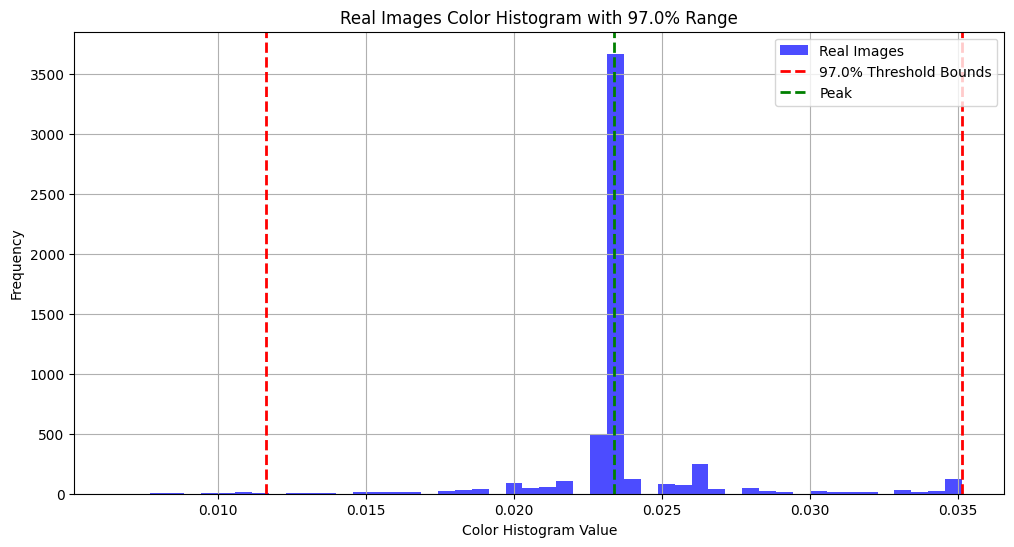

In [9]:
# Define confidence level (e.g., 99%)
confidence_percent = 97.0

# Find the peak in real_histogram_values and determine the range for the specified confidence level
# Find the peak in real_histogram_values using kernel density estimation
kde_real = stats.gaussian_kde(real_histogram_values)
x_vals_real = np.linspace(min(real_histogram_values), max(real_histogram_values), 1000)
y_vals_real = kde_real(x_vals_real)
peak_x_real = x_vals_real[np.argmax(y_vals_real)]
print(f"Highest peak in real images found at: {peak_x_real:.6f}")

# Calculate the percentiles to capture the specified confidence level
lower_percentile = (100 - confidence_percent) / 2
upper_percentile = 100 - lower_percentile
lower_percentile_real = np.percentile(real_histogram_values, lower_percentile)
upper_percentile_real = np.percentile(real_histogram_values, upper_percentile)
print(f"Lower bound ({lower_percentile:.1f}th percentile): {lower_percentile_real:.6f}")
print(f"Upper bound ({upper_percentile:.1f}th percentile): {upper_percentile_real:.6f}")

# Calculate the +/- value from the peak that would capture the specified confidence level of real images
delta_value = max(abs(peak_x_real - lower_percentile_real), abs(upper_percentile_real - peak_x_real))
print(f"Delta value needed around peak to capture {confidence_percent}% of real images: ±{delta_value:.6f}")

# Set thresholds using this delta
lower_threshold_real = peak_x_real - delta_value
upper_threshold_real = peak_x_real + delta_value
print(f"Adjusted lower threshold: {lower_threshold_real:.6f}")
print(f"Adjusted upper threshold: {upper_threshold_real:.6f}")

# Count how many real images actually fall within this range
real_in_range_count = sum(lower_threshold_real <= val <= upper_threshold_real for val in real_histogram_values)
real_in_range_percentage = real_in_range_count / len(real_histogram_values) * 100
print(f"Real images within range: {real_in_range_count} ({real_in_range_percentage:.2f}%)")

# Plot the real images histogram with threshold lines
plt.figure(figsize=(12, 6))
plt.hist(real_histogram_values, bins=50, alpha=0.7, color='blue', label='Real Images')
plt.axvline(lower_threshold_real, color='red', linestyle='dashed', linewidth=2, label=f'{confidence_percent}% Threshold Bounds')
plt.axvline(upper_threshold_real, color='red', linestyle='dashed', linewidth=2)
plt.axvline(peak_x_real, color='green', linestyle='dashed', linewidth=2, label='Peak')
plt.title(f'Real Images Color Histogram with {confidence_percent}% Range')
plt.xlabel('Color Histogram Value')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

Highest peak in mixed images found at: 0.039745
Mixed images lower threshold: 0.027993
Mixed images upper threshold: 0.051496
Mixed images within peak range: 2638 (55.81%)
Mixed images outside peak range: 2089 (44.19%)


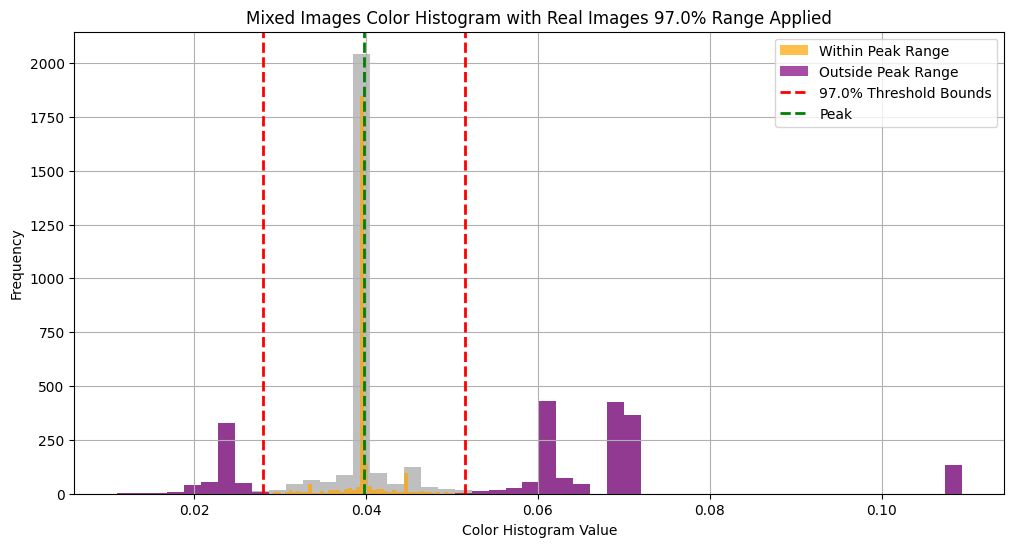

In [10]:
# Find the peak in histogram_values (mixed images) and apply the same +/- delta
# Find the peak in mixed images
kde_mixed = stats.gaussian_kde(histogram_values)
x_vals_mixed = np.linspace(min(histogram_values), max(histogram_values), 1000)
y_vals_mixed = kde_mixed(x_vals_mixed)
peak_x_mixed = x_vals_mixed[np.argmax(y_vals_mixed)]
print(f"Highest peak in mixed images found at: {peak_x_mixed:.6f}")

# Apply the same delta value from real images
lower_threshold_mixed = peak_x_mixed - delta_value
upper_threshold_mixed = peak_x_mixed + delta_value
print(f"Mixed images lower threshold: {lower_threshold_mixed:.6f}")
print(f"Mixed images upper threshold: {upper_threshold_mixed:.6f}")

# Classify mixed images based on thresholds
classifications = np.zeros(len(histogram_values))
for i, value in enumerate(histogram_values):
    if lower_threshold_mixed <= value <= upper_threshold_mixed:
        classifications[i] = 0  # Values within the range
    else:
        classifications[i] = 1  # Values outside the range

# Count results for mixed images
in_range_count = np.sum(classifications == 0)
out_range_count = np.sum(classifications == 1)
print(f"Mixed images within peak range: {in_range_count} ({in_range_count/len(classifications)*100:.2f}%)")
print(f"Mixed images outside peak range: {out_range_count} ({out_range_count/len(classifications)*100:.2f}%)")

# Add classifications to dataframe
negative_label_images.loc[:, 'peak_class'] = classifications

# Plot the mixed images histogram with the same delta threshold as real images
plt.figure(figsize=(12, 6))
plt.hist(histogram_values, bins=50, alpha=0.5, color='gray')
plt.hist([v for i, v in enumerate(histogram_values) if classifications[i] == 0], 
         bins=50, alpha=0.7, color='orange', label='Within Peak Range')
plt.hist([v for i, v in enumerate(histogram_values) if classifications[i] == 1], 
         bins=50, alpha=0.7, color='purple', label='Outside Peak Range')
plt.axvline(lower_threshold_mixed, color='red', linestyle='dashed', linewidth=2, label=f'{confidence_percent}% Threshold Bounds')
plt.axvline(upper_threshold_mixed, color='red', linestyle='dashed', linewidth=2)
plt.axvline(peak_x_mixed, color='green', linestyle='dashed', linewidth=2, label='Peak')
plt.title(f'Mixed Images Color Histogram with Real Images {confidence_percent}% Range Applied')
plt.xlabel('Color Histogram Value')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

In [11]:
# Function to read image and compute color histogram mean using 3D histogram
def compute_color_histogram(image_path):
    # Read the image
    image = cv2.imread(image_path)
    if image is None:
        print(f"Error: Unable to read image at {image_path}")
        return None, None, None
    
    # Convert BGR to RGB for display
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Calculate histograms for each channel (for visualization)
    hist_b = cv2.calcHist([image], [0], None, [256], [0, 256])
    hist_g = cv2.calcHist([image], [1], None, [256], [0, 256])
    hist_r = cv2.calcHist([image], [2], None, [256], [0, 256])
    
    # Calculate the 3D color histogram and its mean as in the original code
    full_hist = cv2.calcHist([image], [0, 1, 2], None, [256, 256, 256], [0, 256, 0, 256, 0, 256])
    mean_value = full_hist.flatten().mean()
    
    return image_rgb, (hist_b, hist_g, hist_r), mean_value

In [12]:
# Function to get n indices from a sorted array based on different criteria
def get_extreme_indices(values, n, from_end='left'):
    # Sort the values
    sorted_indices = np.argsort(values)
    
    if from_end == 'left':
        # Get n indices from the start (lowest values)
        selected_indices = sorted_indices[:n]
    elif from_end == 'right':
        # Get n indices from the end (highest values)
        selected_indices = sorted_indices[-n:]
    elif from_end == 'peak':
        # Get indices closest to the peak (using median value)
        peak_value = np.median(values)
        peak_diff = np.abs(np.array(values) - peak_value)
        selected_indices = np.argsort(peak_diff)[:n]
    
    return selected_indices

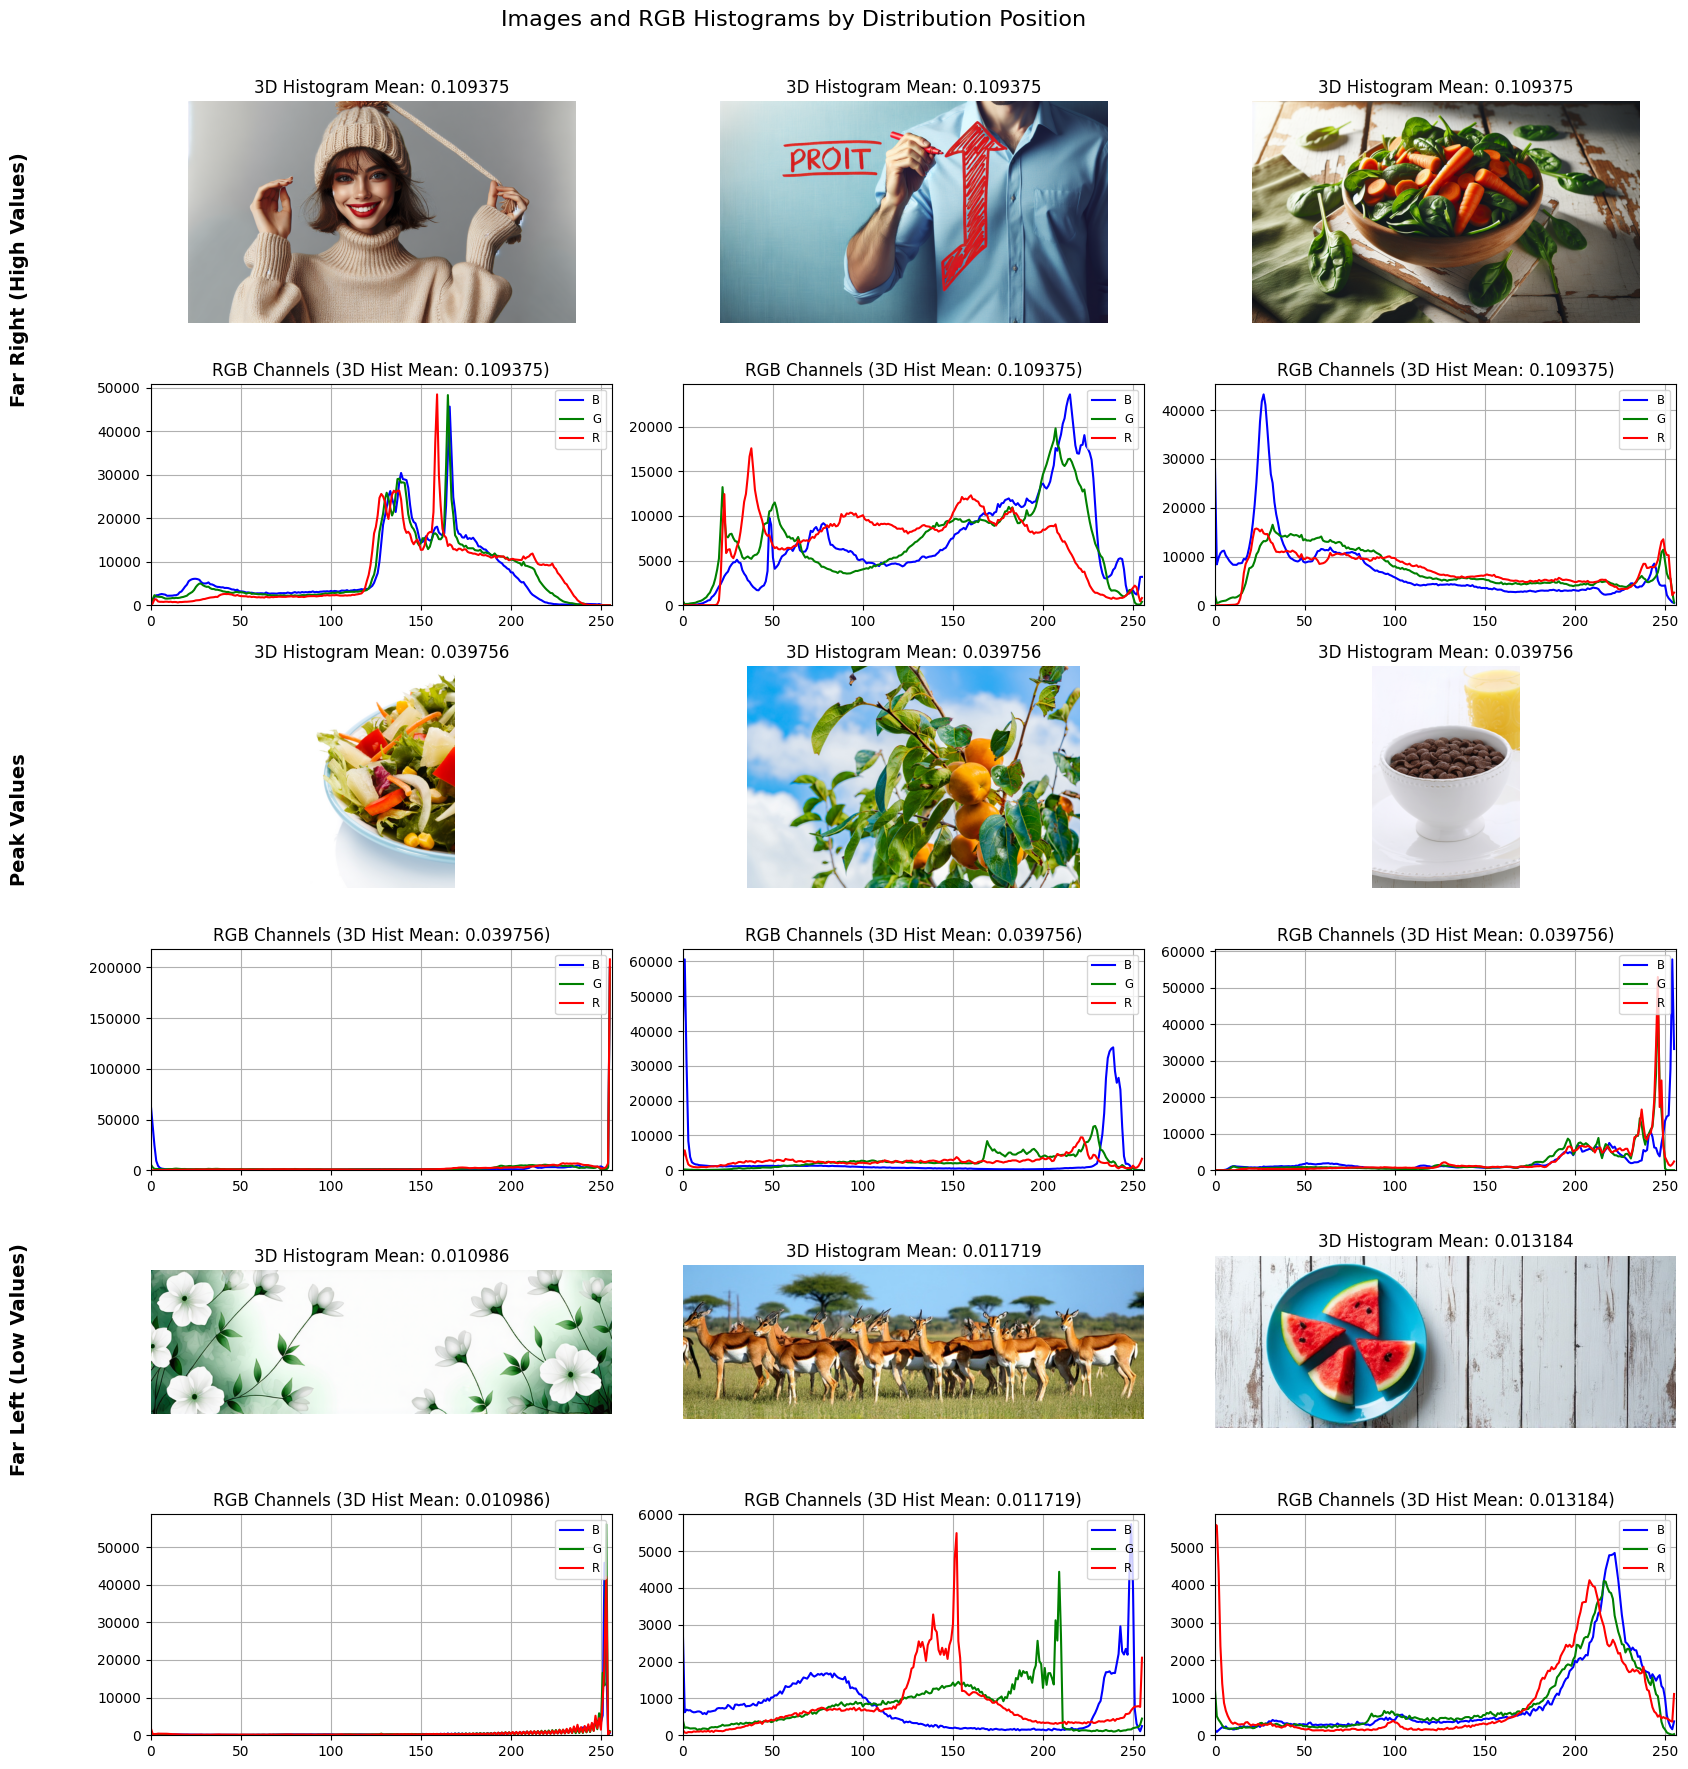

In [13]:
# Get 3 examples from each area of the distribution
n_examples = 3
left_extreme_indices = get_extreme_indices(histogram_values, n_examples, from_end='left')
peak_indices = get_extreme_indices(histogram_values, n_examples, from_end='peak')
right_extreme_indices = get_extreme_indices(histogram_values, n_examples, from_end='right')

# Create a figure with 3 rows (left, peak, right) x 3 columns (3 examples each)
fig = plt.figure(figsize=(18, 18))

# Define row titles in new order (far right first, peak in middle, far left last)
row_titles = ["Far Right (High Values)", "Peak Values", "Far Left (Low Values)"]

# Define the sets of indices to use for each row in the new order
all_indices = [right_extreme_indices, peak_indices, left_extreme_indices]

# Create the grid of images and histograms
for row in range(3):
    # Add row title to the left of the first image in each row
    fig.text(0.07, 0.83 - row * 0.3, row_titles[row], 
             fontsize=14, fontweight='bold', ha='center', va='center',
             rotation=90)
             
    for col in range(3):
        # Get index for this grid position
        img_idx = all_indices[row][col]
        
        # Get image path and histogram value
        image_path = negative_label_images.iloc[img_idx]['full_path']
        hist_value = histogram_values[img_idx]
        
        # Load the image and get its histograms
        image, channel_hists, mean_value = compute_color_histogram(image_path)
        
        # Position for image
        ax_img = plt.subplot2grid((6, 9), (2*row, 3*col), colspan=3, rowspan=1)
        
        if image is None:
            ax_img.text(0.5, 0.5, "Image not found", ha='center', va='center')
            continue
        
        # Display the image
        ax_img.imshow(image)
        ax_img.set_title(f"3D Histogram Mean: {hist_value:.6f}")
        ax_img.axis('off')
        
        # Position for histogram
        ax_hist = plt.subplot2grid((6, 9), (2*row+1, 3*col), colspan=3, rowspan=1)
        
        # Plot channel histograms
        colors = ('b', 'g', 'r')
        for i, color in enumerate(colors):
            ax_hist.plot(channel_hists[i], color=color, label=f"{color.upper()}")
        
        ax_hist.set_xlim([0, 256])
        ax_hist.set_ylim(bottom=0)
        ax_hist.grid(True)
        ax_hist.legend(loc='upper right', fontsize='small')
        ax_hist.set_title(f"RGB Channels (3D Hist Mean: {hist_value:.6f})")

# Apply tight layout
plt.tight_layout(rect=[0.1, 0, 1, 0.95])

plt.suptitle("Images and RGB Histograms by Distribution Position", fontsize=16, y=0.98)
plt.show()

In [14]:
image_to_class = dict(zip(negative_label_images['id'], negative_label_images['peak_class']))

# Update the pred_labels dataframe
for idx, row in pred_labels.iterrows():
    if row['id'] in image_to_class:
        # If this was one of our negative labeled images, update it
        # Convert from the 0/1 in peak_class to -1/1 in label
        if image_to_class[row['id']] == 1:
            pred_labels.at[idx, 'label'] = 1
        else:
            pred_labels.at[idx, 'label'] = 0

# Verify the changes
print(f"Number of images labeled 1: {len(pred_labels[pred_labels['label'] == 1])}")
print(f"Number of images labeled 0: {len(pred_labels[pred_labels['label'] == 0])}")

Number of images labeled 1: 2902
Number of images labeled 0: 2638


In [15]:
# Save submission
pred_labels[['id', 'label']].to_csv('submission1.csv', index=False)
submission1 = pred_labels[['id', 'label']]

In [16]:
df

,id,label
0,test_data_v2/1a2d9fd3e21b4266aea1f66b30aed157.jpg,0.979000
1,test_data_v2/ab5df8f441fe4fbf9dc9c6baae699dc7.jpg,0.010650
2,test_data_v2/eb364dd2dfe34feda0e52466b7ce7956.jpg,0.006180
3,test_data_v2/f76c2580e9644d85a741a42c6f6b39c0.jpg,0.007330
4,test_data_v2/a16495c578b7494683805484ca27cf9f.jpg,0.009056
...,...,...
5535,test_data_v2/483412064ff74d9d9472d606b65976d9.jpg,0.007637
5536,test_data_v2/c0b49ba4081a4197b422dac7c15aea7f.jpg,0.007710
5537,test_data_v2/01454aaedec140c0a3ca1f48028c41cf.jpg,0.007652
5538,test_data_v2/e9adfea8b67e4791968c4c2bdd8ec343.jpg,0.991700


In [17]:
USE_DYNAMIC_THRESHOLD = True

probabilities_df = df.copy()

if USE_DYNAMIC_THRESHOLD:
    # Calculate the median of the probabilities
    threshold = probabilities_df['label'].median()
    print(f"Median probability for class 1: {threshold}")
else:
    threshold = 0.5
    print(f"Threshold: {threshold}")

# Use the median as the threshold to generate the submission.csv
submission_df = probabilities_df.copy()
submission_df['label'] = (submission_df['label'] > threshold).astype(int)
submission_csv_path = "submission2.csv"
submission_df[['id', 'label']].to_csv(submission_csv_path, index=False)
submission2 = submission_df[['id', 'label']]

Median probability for class 1: 0.01106


# CNN

In [18]:
df.rename(columns={'id': 'file_name'}, inplace=True)

In [19]:
df_1 = df[df['label'] >= 0.9]

In [20]:
train_df = pd.read_csv('/kaggle/input/ai-vs-human-generated-dataset/train.csv')
test_df  = pd.read_csv('/kaggle/input/ai-vs-human-generated-dataset/test.csv')
img_dir  = '/kaggle/input/ai-vs-human-generated-dataset/'

# --- Create Pair IDs and Split Train/Validation (Pair-Aware) ---
train_df['pair_id'] = train_df.index // 2
unique_pairs = train_df['pair_id'].unique()

In [21]:
from sklearn.model_selection import train_test_split

train_pairs, val_pairs = train_test_split(unique_pairs, test_size=0.2, random_state=42, shuffle=True)
train_df_split = train_df[train_df['pair_id'].isin(train_pairs)].reset_index(drop=True)
val_df_split   = train_df[train_df['pair_id'].isin(val_pairs)].reset_index(drop=True)
print("Training samples:", len(train_df_split), "Validation samples:", len(val_df_split))

Training samples: 63960 Validation samples: 15990


In [22]:
train_df_split = train_df_split.drop(columns=['pair_id'])
val_df_split = val_df_split.drop(columns=['pair_id'])

In [23]:
train_df_split = train_df_split[['file_name','label']]
val_df_split = val_df_split[['file_name','label']]

In [24]:
df_1['label'] = 1
df_1

/tmp/ipykernel_13/3763851092.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_1['label'] = 1


,file_name,label
0,test_data_v2/1a2d9fd3e21b4266aea1f66b30aed157.jpg,1
8,test_data_v2/601c646d626d46da8c5fac6653efcfb8.jpg,1
15,test_data_v2/ae9f3fd741dd45f0ae94fce7d0b3ab6b.jpg,1
16,test_data_v2/a42e0b2c275242feaf8618d0c74fc419.jpg,1
22,test_data_v2/ed65b1d1ca1f40a6b96a2d317a350a76.jpg,1
...,...,...
5519,test_data_v2/0c8f0b0979f54a5a9f11ad7c16e5c930.jpg,1
5520,test_data_v2/a96aa1390b2e420bbf502d64151902ee.jpg,1
5522,test_data_v2/7951d17f4c0b4a31b72f925c50351db8.jpg,1
5524,test_data_v2/76225a0430f746a19d4d988d5414ea31.jpg,1


In [25]:
train_df_split = pd.concat([train_df_split, df_1], axis=0)

In [26]:
val_df_split

,file_name,label
0,train_data/615df26ce9494e5db2f70e57ce7a3a4f.jpg,1
1,train_data/8542fe161d9147be8e835e50c0de39cd.jpg,0
2,train_data/4aea3b876247467c8d3713d4920148ab.jpg,1
3,train_data/09708379751e44d0bc908d8652d0db3e.jpg,0
4,train_data/340014208f2e46afb5fb1b0837bf52cf.jpg,1
...,...,...
15985,train_data/6b1ff1012c1548aab654332c137eb671.jpg,0
15986,train_data/e8b300ea15c241eb86d6bcbaeb8bcc88.jpg,1
15987,train_data/7fc10ff45ee04fe49e5f45b7ebc0a9b3.jpg,0
15988,train_data/fe6616e4ed6647aab6af65bba94dd599.jpg,1


In [27]:
train_df_split

,file_name,label
0,train_data/a6dcb93f596a43249135678dfcfc17ea.jpg,1
1,train_data/041be3153810433ab146bc97d5af505c.jpg,0
2,train_data/5d81fa12bc3b4cea8c94a6700a477cf2.jpg,1
3,train_data/25ea852f30594bc5915eb929682af429.jpg,0
4,train_data/e67085fb6d814cbabe08f978c738f3f7.jpg,1
...,...,...
5519,test_data_v2/0c8f0b0979f54a5a9f11ad7c16e5c930.jpg,1
5520,test_data_v2/a96aa1390b2e420bbf502d64151902ee.jpg,1
5522,test_data_v2/7951d17f4c0b4a31b72f925c50351db8.jpg,1
5524,test_data_v2/76225a0430f746a19d4d988d5414ea31.jpg,1


In [28]:
test = pd.read_csv('/kaggle/input/ai-vs-human-generated-dataset/test.csv')
test

,id
0,test_data_v2/1a2d9fd3e21b4266aea1f66b30aed157.jpg
1,test_data_v2/ab5df8f441fe4fbf9dc9c6baae699dc7.jpg
2,test_data_v2/eb364dd2dfe34feda0e52466b7ce7956.jpg
3,test_data_v2/f76c2580e9644d85a741a42c6f6b39c0.jpg
4,test_data_v2/a16495c578b7494683805484ca27cf9f.jpg
...,...
5535,test_data_v2/483412064ff74d9d9472d606b65976d9.jpg
5536,test_data_v2/c0b49ba4081a4197b422dac7c15aea7f.jpg
5537,test_data_v2/01454aaedec140c0a3ca1f48028c41cf.jpg
5538,test_data_v2/e9adfea8b67e4791968c4c2bdd8ec343.jpg


In [29]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from tqdm import tqdm
import pandas as pd
import numpy as np

In [30]:
class ImageDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, 'file_name']
        label = int(self.df.loc[idx, 'label'])
        image = Image.open("/kaggle/input/ai-vs-human-generated-dataset/"+img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label

In [31]:
train_transforms = transforms.Compose([
    transforms.Resize((128, 128)),          # resize images
    transforms.RandomHorizontalFlip(),      # data augmentation
    transforms.ToTensor(),                  # convert to tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])  # ImageNet normalization
])

val_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

In [32]:
train_dataset = ImageDataset(train_df_split, transform=train_transforms)
val_dataset = ImageDataset(val_df_split, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

In [33]:
class FakeImageCNN(nn.Module):
    def __init__(self):
        super(FakeImageCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )

        self.classifier = nn.Sequential(
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

In [34]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FakeImageCNN().to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [35]:
num_epochs = 5
best_val_acc = 0.0

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]"):
        images, labels = images.to(device), labels.float().to(device).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # Validation phase
    model.eval()
    val_loss = 0.0
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]"):
            images, labels = images.to(device), labels.float().to(device).unsqueeze(1)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            preds = (outputs > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total
    print(f"Epoch {epoch+1}: Train Loss={running_loss/len(train_loader):.4f}, Val Loss={val_loss/len(val_loader):.4f}, Val Acc={val_acc:.4f}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_fake_image_cnn.pth")
        print("✅ Saved new best model")

print(f"Training completed! Best validation accuracy: {best_val_acc:.4f}")

Epoch 1/5 [Val]: 100%|██████████| 500/500 [04:11<00:00,  1.99it/s]


Epoch 1: Train Loss=0.3121, Val Loss=0.2272, Val Acc=0.9099
✅ Saved new best model


Epoch 2/5 [Val]: 100%|██████████| 500/500 [03:42<00:00,  2.25it/s]


Epoch 2: Train Loss=0.2335, Val Loss=0.1968, Val Acc=0.9273
✅ Saved new best model


Epoch 3/5 [Val]: 100%|██████████| 500/500 [04:06<00:00,  2.03it/s]


Epoch 3: Train Loss=0.1758, Val Loss=0.1270, Val Acc=0.9523
✅ Saved new best model


Epoch 4/5 [Val]: 100%|██████████| 500/500 [03:40<00:00,  2.27it/s]


Epoch 4: Train Loss=0.1337, Val Loss=0.0953, Val Acc=0.9693
✅ Saved new best model


Epoch 5/5 [Val]: 100%|██████████| 500/500 [03:56<00:00,  2.11it/s]

Epoch 5: Train Loss=0.1127, Val Loss=0.0899, Val Acc=0.9699
✅ Saved new best model
Training completed! Best validation accuracy: 0.9699


In [36]:
test_transform = transforms.Compose([
    transforms.Resize((128, 128)),  # match training image size
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [37]:
class TestImageDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['id']
        image = Image.open("/kaggle/input/ai-vs-human-generated-dataset/"+img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, img_path

In [38]:
test_df = test.copy()
test_dataset = TestImageDataset(test_df, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [39]:
model.load_state_dict(torch.load("best_fake_image_cnn.pth")) 
model.eval()

FakeImageCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=32768, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=256, out_features=1, bias=True)
    (4): Sigmoid()
  )
)

In [40]:
predictions = []

with torch.no_grad():
    for images, paths in test_loader:
        images = images.to(device)
        outputs = model(images)

        # Convert model outputs (sigmoid already applied) to numpy
        probs = outputs.cpu().numpy().flatten()

        # Apply threshold for binary labels
        preds_binary = (probs > 0.5).astype(int)

        # Save image path, predicted label, and probability
        for path, label, prob in zip(paths, preds_binary, probs):
            predictions.append((path, int(label), float(prob)))

In [41]:
# Convert to DataFrame
pred_df = pd.DataFrame(predictions, columns=['id', 'label', 'probability'])

# Save results
pred_df.to_csv("test_predictions_with_probs.csv", index=False)

print("Predictions with probabilities saved to test_predictions_with_probs.csv")
pred_df

Predictions with probabilities saved to test_predictions_with_probs.csv


,id,label,probability
0,test_data_v2/1a2d9fd3e21b4266aea1f66b30aed157.jpg,0,0.300598
1,test_data_v2/ab5df8f441fe4fbf9dc9c6baae699dc7.jpg,1,0.700964
2,test_data_v2/eb364dd2dfe34feda0e52466b7ce7956.jpg,0,0.003480
3,test_data_v2/f76c2580e9644d85a741a42c6f6b39c0.jpg,0,0.001182
4,test_data_v2/a16495c578b7494683805484ca27cf9f.jpg,0,0.015168
...,...,...,...
5535,test_data_v2/483412064ff74d9d9472d606b65976d9.jpg,0,0.012656
5536,test_data_v2/c0b49ba4081a4197b422dac7c15aea7f.jpg,0,0.040743
5537,test_data_v2/01454aaedec140c0a3ca1f48028c41cf.jpg,0,0.014996
5538,test_data_v2/e9adfea8b67e4791968c4c2bdd8ec343.jpg,0,0.279296
